# Airplane Crash Fatalities Prediction

## Objective
The goal of this project is to build regression models to predict the number of fatalities in airplane crashes using historical data. The workflow follows a structured data science process: data understanding, preprocessing, model development, evaluation, and prediction on unseen data.

## Data Science Workflow
1. Data Loading and Initial Inspection  
2. Data Cleaning and Preprocessing  
3. Feature Selection and Engineering  
4. Train/Test Split (to prevent data leakage)  
5. Model Selection and Training  
6. Hyperparameter Tuning  
7. Model Evaluation and Comparison  
8. Prediction on Unseen Data  

## Key Assumptions and Constraints
- Missing values are handled based on data type and relevance  
- Only features available at prediction time are used  
- Data leakage is avoided by splitting before transformations  
- Models are evaluated using unseen test data to simulate real-world performance  


# Airplane Crash Fatalities Prediction (Regression)

## Project Aim
This notebook builds a **regression model** to predict the number of **fatalities** in an airplane crash record.

This is the regression equivalent of the earlier Brainstroke project, but the target is now **continuous / count-like** (`Fatalities`) rather than a binary class.  
Because of that, this notebook evaluates models with **regression metrics** such as:

- **MAE (Mean Absolute Error)** – average size of the prediction error in fatalities.
- **RMSE (Root Mean Squared Error)** – similar to MAE, but penalises large errors more heavily.
- **R²** – how much variance in fatalities is explained by the model.


## Model Selection and Justification

Multiple regression models are used to compare performance and justify the final choice.

### 1. Simple Linear Regression
- Used as a baseline model
- Helps understand the relationship between a single predictor and fatalities
- Useful for checking whether a very simple model is already competitive

### 2. Multiple Linear Regression
- Extends the baseline by incorporating multiple engineered predictors
- Assumes an approximately linear relationship between predictors and fatalities
- Provides an interpretable benchmark before moving to regularised models

### 3. Polynomial Regression
- Captures non-linear relationships by transforming selected numerical predictors
- Degree is selected using Bayesian Information Criterion (BIC)
- Included to test whether added flexibility improves performance enough to justify the extra complexity

### 4. Ridge Regression
- Addresses multicollinearity and overfitting with **L2 regularisation**
- Regularisation strength (`alpha`) is tuned using a validation split taken from the training data only
- Useful when many encoded features are correlated

### 5. Lasso Regression (extracurricular technique)
- Adds **L1 regularisation**, which can shrink some coefficients exactly to zero
- This acts as a built-in feature selection method while still performing regression
- Included as an extracurricular extension beyond the core models to demonstrate additional understanding of regularisation and model simplification

## Parameter Justification
- **Polynomial degree:** selected using BIC so that fit is balanced against model complexity  
- **Ridge alpha:** tuned on training-only validation data to control overfitting while preserving predictive performance  
- **Lasso alpha:** tuned on training-only validation data to balance prediction quality and coefficient shrinkage  
- **Train/test split:** ensures fair evaluation on unseen data  
- **Shared preprocessing:** ensures each model is compared under the same leakage-safe feature engineering framework  



### Additional Lasso documentation
After the final Lasso model is fitted, the notebook counts the **non-zero coefficients**. This is included to demonstrate the feature-selection behaviour of Lasso: coefficients shrunk to exactly zero are effectively removed from the model. This provides extra interpretation beyond predictive accuracy and strengthens the justification for including Lasso as an extracurricular technique.


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 1. Load the datasets

- `Airplane_Crashes_and_Fatalities_Since_1908_data.csv` is used for training/testing.
- `Airplane_Crashes_and_Fatalities_Since_1908_unseen.csv` is used at the end for final predictions.

The notebook assumes the CSV files are in the **same folder** as this notebook.


In [2]:
df = pd.read_csv("./processed_datasets/airplanes/Airplane_Crashes_and_Fatalities_Since_1908_data.csv")
df_unseen = pd.read_csv("./processed_datasets/airplanes/Airplane_Crashes_and_Fatalities_Since_1908_unseen.csv")

print("Training shape:", df.shape)
print("Unseen shape:", df_unseen.shape)

df.head()

Training shape: (4741, 13)
Unseen shape: (527, 12)


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
1,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
2,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
3,03/05/1915,01:00,"Tienen, Belgium",Military - German Navy,NaN,NaN,Zeppelin L-8 (airship),NaN,NaN,41.0,21.0,0.0,Crashed into trees while attempting to land af...
4,09/03/1915,15:20,"Off Cuxhaven, Germany",Military - German Navy,NaN,NaN,Zeppelin L-10 (airship),NaN,NaN,19.0,19.0,0.0,"Exploded and burned near Neuwerk Island, when..."


## 2. Initial data understanding

Before modelling, it is important to inspect:
- data types,
- missing values,
- the target variable,
- and whether the target looks skewed.

This supports the modelling choices later in the notebook.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4741 entries, 0 to 4740
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          4741 non-null   object 
 1   Time          2741 non-null   object 
 2   Location      4724 non-null   object 
 3   Operator      4726 non-null   object 
 4   Flight #      967 non-null    object 
 5   Route         3196 non-null   object 
 6   Type          4717 non-null   object 
 7   Registration  4441 non-null   object 
 8   cn/In         3643 non-null   object 
 9   Aboard        4722 non-null   float64
 10  Fatalities    4730 non-null   float64
 11  Ground        4721 non-null   float64
 12  Summary       4388 non-null   object 
dtypes: float64(3), object(10)
memory usage: 481.6+ KB


In [4]:
# Missing-value summary
missing_summary = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename("missing_percent")
      .to_frame()
)

missing_summary

,missing_percent
Flight #,79.603459
Time,42.185193
Route,32.588062
cn/In,23.159671
Summary,7.445687
Registration,6.327779
Type,0.506222
Ground,0.421852
Aboard,0.400759
Location,0.358574


In [5]:
# Target summary
df["Fatalities"].describe()

count    4730.000000
mean       20.009725
std        33.142890
min         0.000000
25%         3.000000
50%         9.000000
75%        22.000000
max       583.000000
Name: Fatalities, dtype: float64

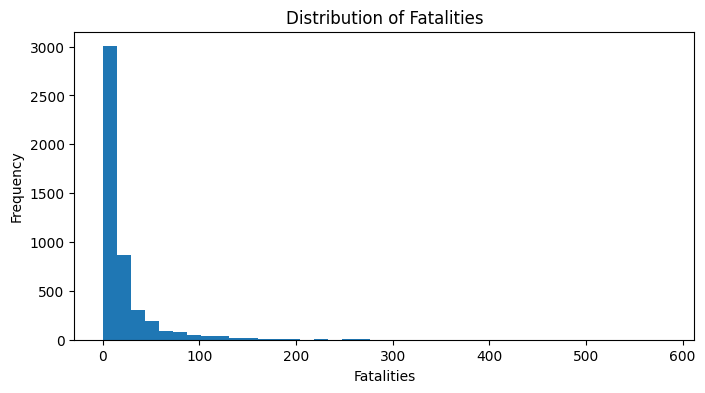

Skewness of Fatalities: 4.995816782514751


In [6]:
# Distribution of the target variable
plt.figure(figsize=(8, 4))
plt.hist(df["Fatalities"].dropna(), bins=40)
plt.title("Distribution of Fatalities")
plt.xlabel("Fatalities")
plt.ylabel("Frequency")
plt.show()

print("Skewness of Fatalities:", df["Fatalities"].dropna().skew())

### Why this matters
The target is strongly right-skewed, which is common for accident severity data:
- many crashes have relatively lower fatalities,
- a smaller number of crashes have very high fatalities.

Because of this, a **log transformation of the target** is a sensible modelling choice for some models.  
It helps reduce the influence of extreme values during training while still allowing predictions to be returned on the original fatalities scale.


## 3. Data cleaning and feature engineering

The raw dataset contains many text fields and date/time strings.  
To make the data more useful for regression, we engineer structured features:

- **Date** → `year`, `month`, `day`, `dayofweek`
- **Time** → `hour`, `minute`
- **Location** → simplified `country_bucket`
- **Type** → simplified `type_bucket`
- **Operator** → simplified `operator_bucket`
- **Route** → estimated `route_stops`
- **Summary** → text length as `summary_len`

This keeps the model interpretable and avoids over-complicating the notebook with very sparse text modelling.


In [7]:
def get_country(location):
    """Extract the final comma-separated part of Location as a simplified country/region field."""
    if pd.isna(location):
        return np.nan

    parts = [part.strip() for part in str(location).split(",")]
    return parts[-1] if parts else np.nan


def engineer_features(dataframe):
    """Create model-ready features from the raw crash dataset."""
    data = dataframe.copy()

    # Date-based features
    data["date_parsed"] = pd.to_datetime(data["Date"], errors="coerce")
    data["year"] = data["date_parsed"].dt.year
    data["month"] = data["date_parsed"].dt.month
    data["day"] = data["date_parsed"].dt.day
    data["dayofweek"] = data["date_parsed"].dt.dayofweek

    # Time-based features
    time_parsed = pd.to_datetime(data["Time"], format="%H:%M", errors="coerce")
    data["hour"] = time_parsed.dt.hour
    data["minute"] = time_parsed.dt.minute

    # Simplified categorical features
    data["country"] = data["Location"].apply(get_country)
    data["type_family"] = data["Type"].fillna("Unknown").astype(str).str.split().str[0]

    # Simple numeric proxies from text columns
    data["route_stops"] = data["Route"].fillna("").astype(str).str.count("-") + 1
    data.loc[data["Route"].isna(), "route_stops"] = np.nan
    data["summary_len"] = data["Summary"].fillna("").astype(str).str.len()

    return data


class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """
    Learn the most common categories from the training data only and map all
    remaining categories to 'Other'.

    This avoids leaking category frequency information from the test or unseen
    data into the fitted model.
    """

    def __init__(self, top_n_map=None, other_label="Other", missing_label="Unknown"):
        self.top_n_map = top_n_map or {}
        self.other_label = other_label
        self.missing_label = missing_label

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        X.columns = list(self.top_n_map.keys())
        self.feature_names_in_ = list(X.columns)
        self.top_categories_ = {}

        for col, top_n in self.top_n_map.items():
            values = X[col].fillna(self.missing_label).astype(str)
            self.top_categories_[col] = list(values.value_counts().head(top_n).index)

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.columns = self.feature_names_in_
        grouped = pd.DataFrame(index=X.index)

        for col in self.feature_names_in_:
            values = X[col].fillna(self.missing_label).astype(str)
            keep_values = self.top_categories_.get(col, [])
            grouped[col] = np.where(values.isin(keep_values), values, self.other_label)

        return grouped

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_, dtype=object)


In [8]:
# Apply feature engineering before the split.
# This step is safe because it uses row-level transformations only and does not
# learn any statistics from the whole dataset.
df_model = engineer_features(df)
df_unseen_model = engineer_features(df_unseen)

df_model.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,...,year,month,day,dayofweek,hour,minute,country,type_family,route_stops,summary_len
0,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,...,1912,7,12,4,6.0,30.0,New Jersey,Dirigible,1.0,99
1,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,...,1913,8,6,2,NaN,NaN,Canada,Curtiss,NaN,126
2,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,...,1913,9,9,1,18.0,30.0,Over the North Sea,Zeppelin,NaN,212
3,03/05/1915,01:00,"Tienen, Belgium",Military - German Navy,NaN,NaN,Zeppelin L-8 (airship),NaN,NaN,41.0,...,1915,3,5,4,1.0,0.0,Belgium,Zeppelin,NaN,97
4,09/03/1915,15:20,"Off Cuxhaven, Germany",Military - German Navy,NaN,NaN,Zeppelin L-10 (airship),NaN,NaN,19.0,...,1915,9,3,4,15.0,20.0,Germany,Zeppelin,NaN,100


## 4. Exploratory Data Analysis (EDA)

This section gives useful context for the modelling stage.

The goal is not just to make plots, but to check whether the data patterns make sense:
- Do higher passenger counts relate to higher fatalities?
- Are fatalities highly skewed?
- Which operators or aircraft families appear most often?


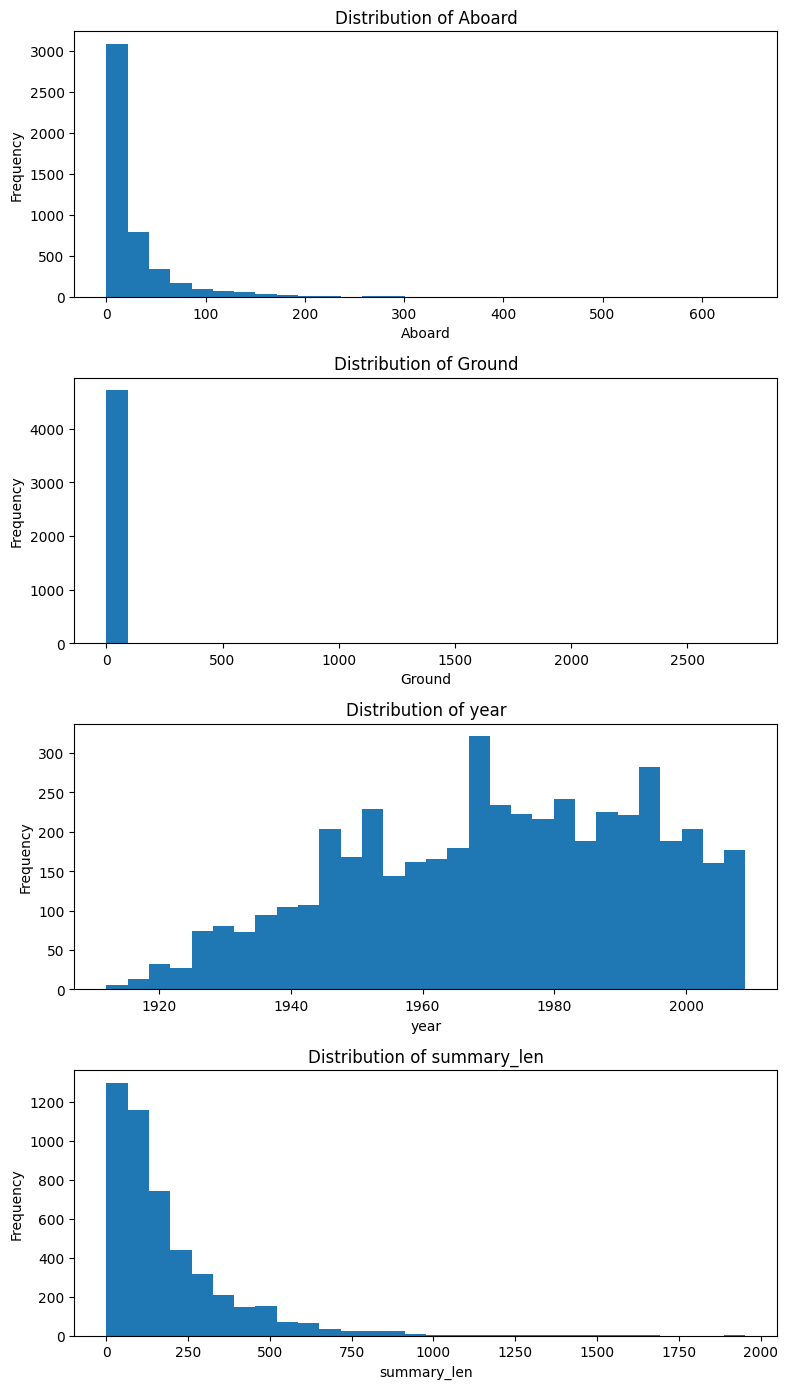

In [9]:
# Numerical columns to inspect
eda_num_cols = ["Aboard", "Ground", "year", "summary_len"]

fig, axes = plt.subplots(len(eda_num_cols), 1, figsize=(8, 14))

for ax, col in zip(axes, eda_num_cols):
    ax.hist(df_model[col].dropna(), bins=30)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

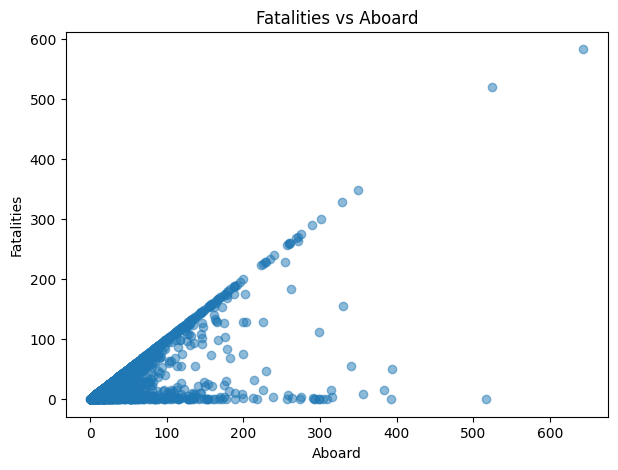

Correlation between Aboard and Fatalities:
              Aboard  Fatalities
Aboard      1.000000    0.744574
Fatalities  0.744574    1.000000


In [10]:
# Fatalities vs Aboard
plot_df = df_model.dropna(subset=["Aboard", "Fatalities"]).copy()

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["Aboard"], plot_df["Fatalities"], alpha=0.5)
plt.title("Fatalities vs Aboard")
plt.xlabel("Aboard")
plt.ylabel("Fatalities")
plt.show()

print("Correlation between Aboard and Fatalities:")
print(plot_df[["Aboard", "Fatalities"]].corr())

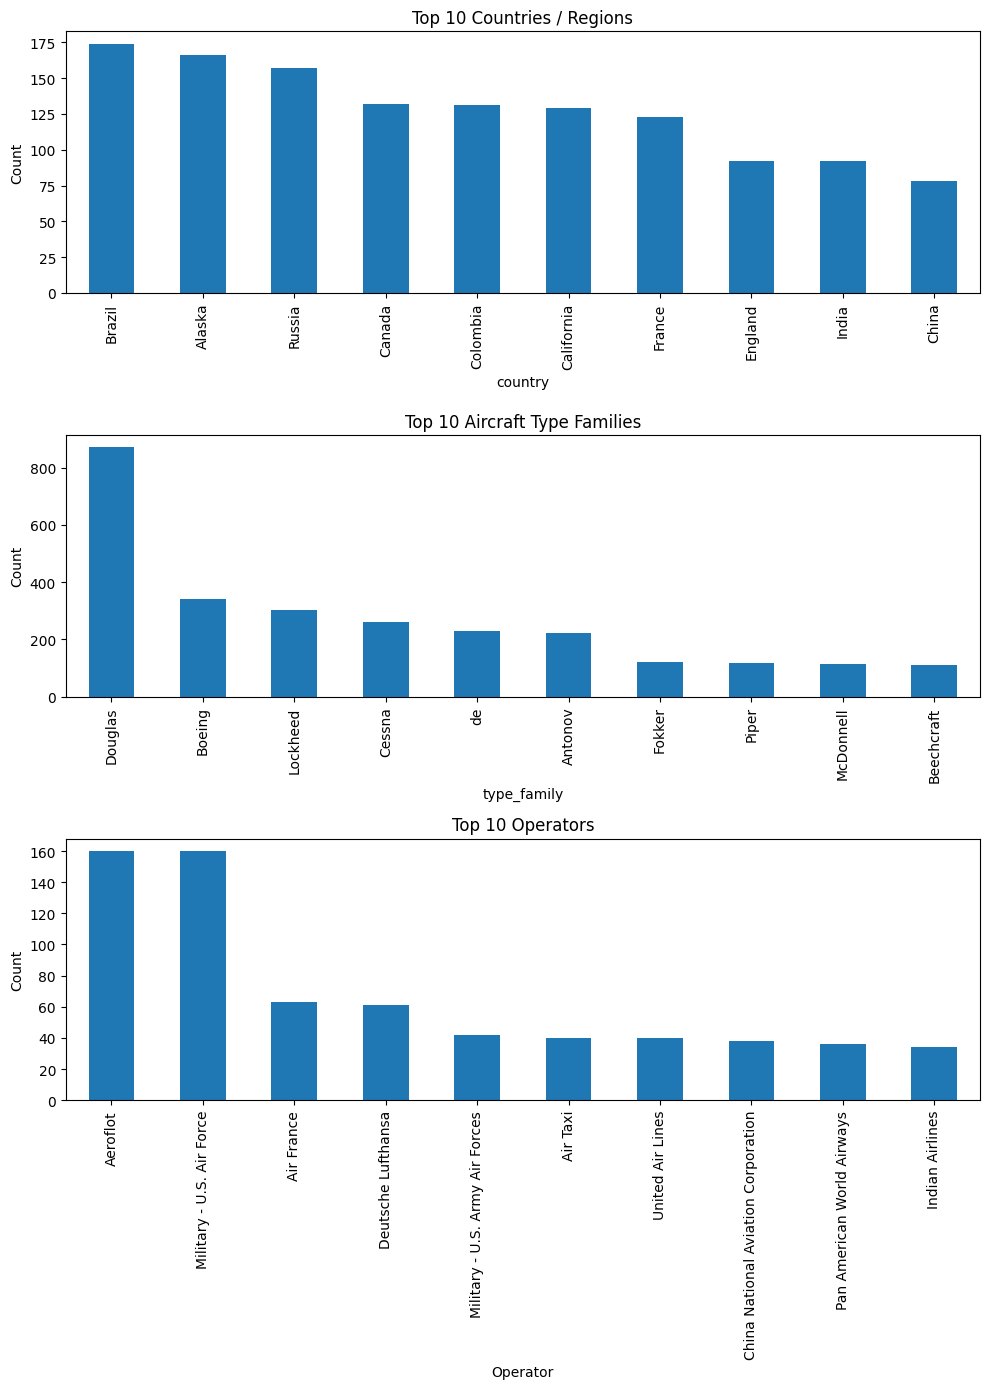

In [11]:
# Top categories for crash records (raw engineered categories before train-only grouping)
fig, axes = plt.subplots(3, 1, figsize=(10, 14))

df_model["country"].fillna("Unknown").value_counts().head(10).plot(kind="bar", ax=axes[0], title="Top 10 Countries / Regions")
df_model["type_family"].fillna("Unknown").value_counts().head(10).plot(kind="bar", ax=axes[1], title="Top 10 Aircraft Type Families")
df_model["Operator"].fillna("Unknown").value_counts().head(10).plot(kind="bar", ax=axes[2], title="Top 10 Operators")

for ax in axes:
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### EDA takeaways
Some useful observations already appear:

- **Aboard** should be one of the strongest predictors, because fatalities cannot realistically exceed the number of people aboard by a large amount.
- The target remains highly skewed, supporting the decision to test regression models carefully rather than relying on one baseline only.
- The categorical fields are diverse, which justifies grouping rare categories later **inside the training-only pipeline** before one-hot encoding.

These findings directly inform the modelling pipeline below.


## 5. Prepare modelling data

We now define:
- the final feature set,
- the target variable,
- and the train/test split.

The split is done **before** any fitted preprocessing steps such as rare-category grouping,
imputation, scaling, polynomial expansion, or ridge tuning.

This is important because it prevents **data leakage** and ensures the test set remains a fair final evaluation set.


In [12]:
# Drop rows where the target is missing
df_model = df_model.dropna(subset=["Fatalities"]).copy()

feature_cols = [
    "Aboard",
    "Ground",
    "year",
    "month",
    "day",
    "dayofweek",
    "hour",
    "minute",
    "route_stops",
    "summary_len",
    "country",
    "type_family",
    "Operator"
]

target_col = "Fatalities"

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3784, 13)
X_test shape: (946, 13)
y_train shape: (3784,)
y_test shape: (946,)


## 6. Preprocessing strategy

### Why separate preprocessing is needed
- **Simple linear regression** uses only one predictor (`Aboard`) so it needs a very small pipeline.
- **Multiple linear regression**, **ridge regression**, and **lasso regression** use both numerical and categorical predictors, so they need:
  - numerical imputation,
  - scaling for the numerical variables,
  - rare-category grouping learned from the training split,
  - one-hot encoding for categorical variables.
- **Polynomial regression** expands selected numerical variables into squared and interaction terms.  
  This helps the model capture **non-linear relationships** without moving to a non-linear algorithm such as a tree model.

### Why scaling is included
Scaling is especially helpful for:
- **ridge regression**, because L2 regularisation is sensitive to feature magnitude,
- **lasso regression**, because L1 regularisation is also sensitive to feature scale,
- **polynomial regression**, because squared and interaction terms can become much larger than the original features.

### How leakage is avoided
Every fitted transformer that learns something from the data (for example imputation values, rare-category thresholds, scaling parameters, or encoded category levels) is fitted **only on the training data** inside a pipeline.

This means:
- the test set is not used to learn preprocessing parameters,
- model evaluation remains fair,
- and the same learned transformations can later be applied safely to the unseen dataset.



In [13]:
# Define numerical and categorical columns used in the full models
num_cols = [
    "Aboard",
    "Ground",
    "year",
    "month",
    "day",
    "dayofweek",
    "hour",
    "minute",
    "route_stops",
    "summary_len"
]

cat_cols = [
    "country",
    "type_family",
    "Operator"
]

# Simple linear regression uses one explanatory variable only.
simple_feature = ["Aboard"]

# Polynomial regression is applied to a selected subset of numerical variables.
# This keeps the model interpretable and avoids creating an excessively large matrix.
poly_num_cols = [
    "Aboard",
    "Ground",
    "year",
    "month",
    "route_stops",
    "summary_len"
]

cat_pipeline = Pipeline([
    ("rare", RareCategoryGrouper({"country": 25, "type_family": 20, "Operator": 25})),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

simple_preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        simple_feature
    )
])

full_preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        num_cols
    ),
    ("cat", cat_pipeline, cat_cols)
])


def make_poly_preprocessor(degree):
    """Create a polynomial preprocessor for a given degree."""
    return ColumnTransformer([
        (
            "poly_num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("poly", PolynomialFeatures(degree=degree, include_bias=False))
            ]),
            poly_num_cols
        ),
        ("cat", clone(cat_pipeline), cat_cols)
    ])


## 7. Model comparison

This section compares the regression approaches used in the project, including one extracurricular extension.

### Models used
1. **Simple Linear Regression**  
   Uses only one predictor (`Aboard`). It is a clear baseline model.

2. **Multiple Linear Regression**  
   Uses several engineered predictors together.

3. **Polynomial Regression**  
   Tests multiple degrees and uses **BIC** to identify the best polynomial degree.  
   BIC is useful because it rewards good fit but also penalises unnecessary complexity.

4. **Ridge Regression**  
   Extends multiple linear regression by adding **L2 regularisation**.  
   The best alpha is chosen using a **validation split from the training data only**, then the selected alpha is tested on the held-out test set.

5. **Lasso Regression (extracurricular technique)**  
   Extends multiple linear regression by adding **L1 regularisation**.  
   The best alpha is chosen using a **validation split from the training data only**, then the selected alpha is tested on the held-out test set.  
   Lasso is especially useful because it can shrink weaker coefficients to zero, which helps with feature selection and model simplification.



In [14]:
def rmse_score(y_true, y_pred):
    """Return root mean squared error."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def bic_from_predictions(y_true, y_pred, n_params):
    """
    Calculate BIC from prediction errors.

    BIC = n*ln(RSS/n) + k*ln(n)
    where:
    - n = number of observations
    - RSS = residual sum of squares
    - k = number of model parameters (approximated here by transformed features + intercept)
    """
    n = len(y_true)
    rss = np.sum((np.array(y_true) - np.array(y_pred)) ** 2)
    rss = max(rss, 1e-9)
    return n * np.log(rss / n) + n_params * np.log(n)


def cap_predictions_to_aboard(predictions, X_reference):
    """Apply real-world constraints to predicted fatalities."""
    predictions = np.clip(predictions, 0, None)
    if "Aboard" in X_reference.columns:
        aboard_upper = X_reference["Aboard"].fillna(np.inf).to_numpy()
        predictions = np.minimum(predictions, aboard_upper)
    return predictions


def evaluate_regression_model(model_name, pipeline, X_train, X_test, y_train, y_test, extra_metrics=None):
    """Train one regression pipeline and return predictions plus metrics."""
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    predictions = cap_predictions_to_aboard(predictions, X_test)

    results = {
        "model": model_name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": rmse_score(y_test, predictions),
        "R2": r2_score(y_test, predictions)
    }

    if extra_metrics:
        results.update(extra_metrics)

    return pipeline, predictions, results


# 1) Simple linear regression baseline
simple_pipeline = Pipeline([
    ("preprocessor", simple_preprocessor),
    ("model", LinearRegression())
])

simple_fitted, simple_preds, simple_results = evaluate_regression_model(
    model_name="Simple Linear Regression",
    pipeline=simple_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)


# 2) Multiple linear regression
multiple_pipeline = Pipeline([
    ("preprocessor", full_preprocessor),
    ("model", LinearRegression())
])

multiple_fitted, multiple_preds, multiple_results = evaluate_regression_model(
    model_name="Multiple Linear Regression",
    pipeline=multiple_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)


# 3) Polynomial regression: test multiple degrees and select by BIC
poly_degree_results = []
poly_models = {}
poly_predictions = {}

for degree in [1, 2, 3, 4]:
    poly_pipeline = Pipeline([
        ("preprocessor", make_poly_preprocessor(degree)),
        ("model", LinearRegression())
    ])

    poly_pipeline.fit(X_train, y_train)
    degree_preds = poly_pipeline.predict(X_test)
    degree_preds = cap_predictions_to_aboard(degree_preds, X_test)

    transformed_feature_count = poly_pipeline.named_steps["preprocessor"].transform(X_test.iloc[:1]).shape[1]
    degree_bic = bic_from_predictions(y_test, degree_preds, n_params=transformed_feature_count + 1)

    poly_degree_results.append({
        "degree": degree,
        "MAE": mean_absolute_error(y_test, degree_preds),
        "RMSE": rmse_score(y_test, degree_preds),
        "R2": r2_score(y_test, degree_preds),
        "BIC": degree_bic,
        "n_parameters": transformed_feature_count + 1
    })

    poly_models[degree] = poly_pipeline
    poly_predictions[degree] = degree_preds

poly_degree_results_df = pd.DataFrame(poly_degree_results).sort_values("BIC").reset_index(drop=True)
best_degree = int(poly_degree_results_df.loc[0, "degree"])
best_poly_pipeline = poly_models[best_degree]
best_poly_preds = poly_predictions[best_degree]

poly_results = {
    "model": f"Polynomial Regression (degree {best_degree})",
    "MAE": mean_absolute_error(y_test, best_poly_preds),
    "RMSE": rmse_score(y_test, best_poly_preds),
    "R2": r2_score(y_test, best_poly_preds),
    "BIC": poly_degree_results_df.loc[0, "BIC"],
    "selected_degree": best_degree
}


# 4) Ridge regression: choose alpha using training data only
X_ridge_train, X_ridge_val, y_ridge_train, y_ridge_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42
)

alpha_grid = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_validation_results = []

for alpha in alpha_grid:
    ridge_candidate = Pipeline([
        ("preprocessor", clone(full_preprocessor)),
        ("model", Ridge(alpha=alpha))
    ])

    ridge_candidate.fit(X_ridge_train, y_ridge_train)
    val_preds = ridge_candidate.predict(X_ridge_val)
    val_preds = cap_predictions_to_aboard(val_preds, X_ridge_val)

    ridge_validation_results.append({
        "alpha": alpha,
        "validation_MAE": mean_absolute_error(y_ridge_val, val_preds),
        "validation_RMSE": rmse_score(y_ridge_val, val_preds),
        "validation_R2": r2_score(y_ridge_val, val_preds)
    })

ridge_validation_df = pd.DataFrame(ridge_validation_results).sort_values(
    by=["validation_RMSE", "validation_MAE"],
    ascending=[True, True]
).reset_index(drop=True)

best_alpha = float(ridge_validation_df.loc[0, "alpha"])

ridge_pipeline = Pipeline([
    ("preprocessor", clone(full_preprocessor)),
    ("model", Ridge(alpha=best_alpha))
])

ridge_fitted, ridge_preds, ridge_results = evaluate_regression_model(
    model_name=f"Ridge Regression (alpha={best_alpha})",
    pipeline=ridge_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    extra_metrics={"selected_alpha": best_alpha}
)


# 5) Lasso regression (extracurricular): choose alpha using training data only
X_lasso_train, X_lasso_val, y_lasso_train, y_lasso_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42
)

lasso_validation_results = []

for alpha in alpha_grid:
    lasso_candidate = Pipeline([
        ("preprocessor", clone(full_preprocessor)),
        ("model", Lasso(alpha=alpha, max_iter=20000))
    ])

    lasso_candidate.fit(X_lasso_train, y_lasso_train)
    val_preds = lasso_candidate.predict(X_lasso_val)
    val_preds = cap_predictions_to_aboard(val_preds, X_lasso_val)

    non_zero_coefficients = np.sum(lasso_candidate.named_steps["model"].coef_ != 0)

    lasso_validation_results.append({
        "alpha": alpha,
        "validation_MAE": mean_absolute_error(y_lasso_val, val_preds),
        "validation_RMSE": rmse_score(y_lasso_val, val_preds),
        "validation_R2": r2_score(y_lasso_val, val_preds),
        "non_zero_coefficients": int(non_zero_coefficients)
    })

lasso_validation_df = pd.DataFrame(lasso_validation_results).sort_values(
    by=["validation_RMSE", "validation_MAE"],
    ascending=[True, True]
).reset_index(drop=True)

best_lasso_alpha = float(lasso_validation_df.loc[0, "alpha"])

lasso_pipeline = Pipeline([
    ("preprocessor", clone(full_preprocessor)),
    ("model", Lasso(alpha=best_lasso_alpha, max_iter=20000))
])

lasso_fitted, lasso_preds, lasso_results = evaluate_regression_model(
    model_name=f"Lasso Regression (alpha={best_lasso_alpha})",
    pipeline=lasso_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    extra_metrics={
        "selected_alpha": best_lasso_alpha
    }
)

# Count the number of coefficients retained after fitting the final Lasso model.
# This is calculated after training because the fitted coefficients do not exist beforehand.
lasso_results["non_zero_coefficients"] = int(
    np.sum(lasso_fitted.named_steps["model"].coef_ != 0)
)



In [15]:
# Collect the final test-set results for model comparison
all_results = [
    simple_results,
    multiple_results,
    poly_results,
    ridge_results,
    lasso_results
]

results_df = pd.DataFrame(all_results).sort_values(
    by=["RMSE", "MAE"],
    ascending=[True, True]
).reset_index(drop=True)

fitted_models = {
    "Simple Linear Regression": simple_fitted,
    "Multiple Linear Regression": multiple_fitted,
    f"Polynomial Regression (degree {best_degree})": best_poly_pipeline,
    f"Ridge Regression (alpha={best_alpha})": ridge_fitted,
    f"Lasso Regression (alpha={best_lasso_alpha})": lasso_fitted
}

test_predictions = {
    "Simple Linear Regression": simple_preds,
    "Multiple Linear Regression": multiple_preds,
    f"Polynomial Regression (degree {best_degree})": best_poly_preds,
    f"Ridge Regression (alpha={best_alpha})": ridge_preds,
    f"Lasso Regression (alpha={best_lasso_alpha})": lasso_preds
}

print("Polynomial degree selection using BIC:")
display(poly_degree_results_df)

print("Ridge alpha selection using validation data from X_train only:")
display(ridge_validation_df)

print("Lasso alpha selection using validation data from X_train only:")
display(lasso_validation_df)

print("Final test-set comparison across models:")
results_df



Polynomial degree selection using BIC:


,degree,MAE,RMSE,R2,BIC,n_parameters
0,1,8.078766,20.080787,0.550675,6223.731914,80
1,3,7.220952,17.078440,0.674991,6444.951552,157
2,2,7.744643,20.948151,0.511021,6447.635786,101
3,4,7.296864,18.591468,0.614853,7468.938295,283


Ridge alpha selection using validation data from X_train only:


,alpha,validation_MAE,validation_RMSE,validation_R2
0,0.0010,8.413592,19.891142,0.692626
1,0.0100,8.413538,19.891208,0.692624
2,0.1000,8.412841,19.891956,0.692601
3,0.0001,8.414033,19.892138,0.692595
4,1.0000,8.407026,19.899127,0.692379
5,10.0000,8.397119,19.957003,0.690587
6,100.0000,8.474572,20.372638,0.677565
7,1000.0000,9.089531,22.681675,0.600333


Lasso alpha selection using validation data from X_train only:


,alpha,validation_MAE,validation_RMSE,validation_R2,non_zero_coefficients
0,0.0001,8.413167,19.892141,0.692595,80
1,0.0010,8.409290,19.892825,0.692574,80
2,0.0100,8.391881,19.909516,0.692058,74
3,0.1000,8.505438,20.183902,0.683512,26
4,1.0000,8.620070,20.698594,0.667165,4
5,10.0000,9.560180,24.847798,0.520351,1
6,100.0000,11.626159,34.045361,0.099542,0
7,1000.0000,11.626159,34.045361,0.099542,0


Final test-set comparison across models:


,model,MAE,RMSE,R2,BIC,selected_degree,selected_alpha,non_zero_coefficients
0,Polynomial Regression (degree 1),8.078766,20.080787,0.550675,6223.731914,1.0,NaN,NaN
1,Multiple Linear Regression,8.126092,20.191417,0.545711,NaN,NaN,NaN,NaN
2,Lasso Regression (alpha=0.0001),8.126028,20.191778,0.545695,NaN,NaN,0.0001,82.0
3,Ridge Regression (alpha=0.001),8.126177,20.192318,0.545670,NaN,NaN,0.0010,NaN
4,Simple Linear Regression,8.063584,20.476666,0.532785,NaN,NaN,NaN,NaN


### Why these metrics are appropriate

- **MAE** is easy to explain because it tells us the average absolute error in predicted fatalities.
- **RMSE** is useful here because larger mistakes on severe crashes matter more than small mistakes on low-fatality crashes.
- **R²** shows how much variation in fatalities is captured by the model, but it should not be used on its own.
- **BIC** is specifically used for polynomial degree selection because it balances fit against model complexity.

### Model-selection logic used here
- The **best polynomial degree** is chosen using **lowest BIC**.
- The **best ridge alpha** is chosen using **lowest validation RMSE** on a split taken from the training data only.
- The **best lasso alpha** is chosen using **lowest validation RMSE** on a split taken from the training data only.
- The **overall winning model** is then selected using the held-out **test set**, prioritising **lowest RMSE** and then **lowest MAE**.

This approach keeps hyperparameter tuning separate from the final test comparison, which makes the evaluation more reliable.



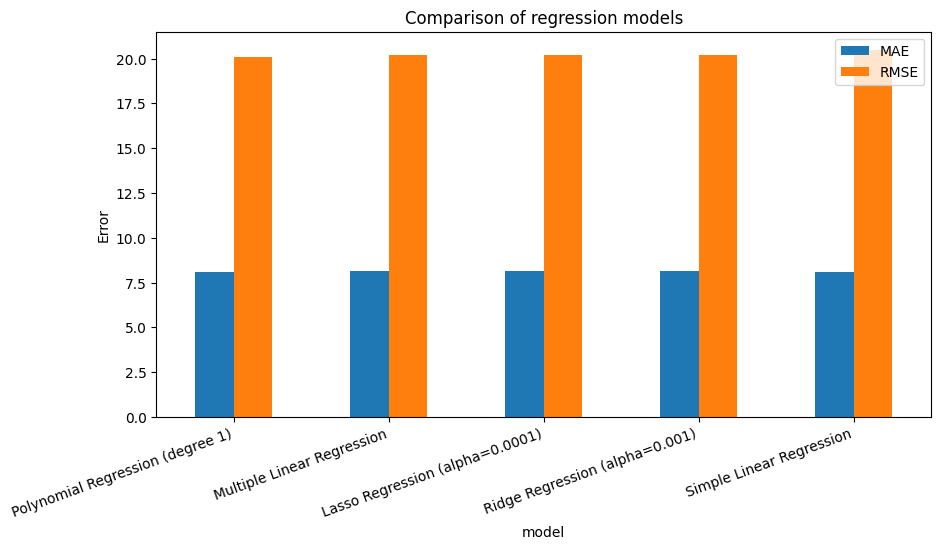

In [16]:
# Visual comparison of model performance
results_plot = results_df.set_index("model")[["MAE", "RMSE"]]

results_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Comparison of regression models")
plt.ylabel("Error")
plt.xticks(rotation=20, ha="right")
plt.show()

In [17]:
# Select the best overall model using the final held-out test set
best_model_name = results_df.loc[0, "model"]
best_pipeline = fitted_models[best_model_name]
best_preds = test_predictions[best_model_name]

print("Best polynomial degree by BIC:", best_degree)
print("Best ridge alpha from training-only validation:", best_alpha)
print("Best lasso alpha from training-only validation:", best_lasso_alpha)
print("Best overall model selected from the test comparison:", best_model_name)

results_df



Best polynomial degree by BIC: 1
Best ridge alpha from training-only validation: 0.001
Best lasso alpha from training-only validation: 0.0001
Best overall model selected from the test comparison: Polynomial Regression (degree 1)


,model,MAE,RMSE,R2,BIC,selected_degree,selected_alpha,non_zero_coefficients
0,Polynomial Regression (degree 1),8.078766,20.080787,0.550675,6223.731914,1.0,NaN,NaN
1,Multiple Linear Regression,8.126092,20.191417,0.545711,NaN,NaN,NaN,NaN
2,Lasso Regression (alpha=0.0001),8.126028,20.191778,0.545695,NaN,NaN,0.0001,82.0
3,Ridge Regression (alpha=0.001),8.126177,20.192318,0.545670,NaN,NaN,0.0010,NaN
4,Simple Linear Regression,8.063584,20.476666,0.532785,NaN,NaN,NaN,NaN


## 8. Evaluate the best model in more detail

After identifying the strongest regression model, it is good practice to look beyond the summary metrics.

The checks below help answer:
- Are predictions broadly aligned with the real values?
- Are the errors centred around zero?
- Which variables appear to matter most in the selected model?

These extra checks strengthen the analysis and improve the written justification for the chosen final model.

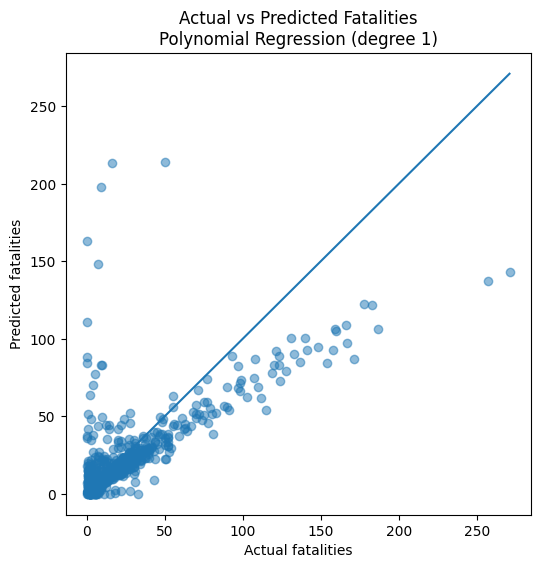

In [18]:
# Actual vs predicted plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title(f"Actual vs Predicted Fatalities\n{best_model_name}")
plt.xlabel("Actual fatalities")
plt.ylabel("Predicted fatalities")
plt.show()

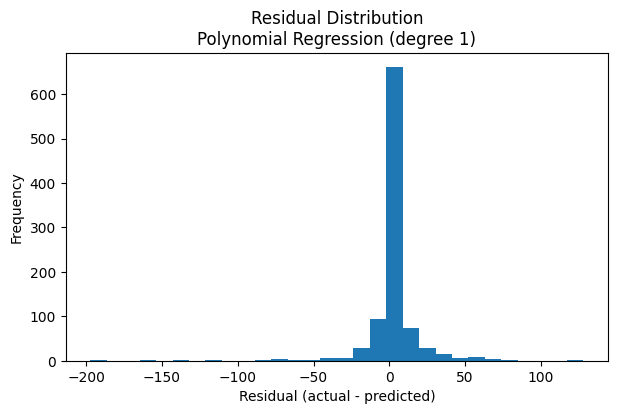

Residual summary:


count    946.000000
mean       1.520322
std       20.033744
min     -197.236736
25%        0.000000
50%        0.000000
75%        4.046742
max      128.048331
Name: Fatalities, dtype: float64

In [19]:
# Residual analysis
residuals = y_test - best_preds

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=30)
plt.title(f"Residual Distribution\n{best_model_name}")
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Frequency")
plt.show()

print("Residual summary:")
pd.Series(residuals).describe()

In [20]:
# Coefficient-based interpretation for the best regression model
# For linear-family models, we can inspect model coefficients after preprocessing.

best_model_step = best_pipeline.named_steps["model"]
best_preprocessor = best_pipeline.named_steps["preprocessor"]

if hasattr(best_model_step, "coef_"):
    try:
        feature_names = best_preprocessor.get_feature_names_out()
    except Exception:
        feature_names = [f"feature_{i}" for i in range(len(best_model_step.coef_))]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": best_model_step.coef_
    })
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

    coef_df.head(15)
else:
    print("This fitted model does not expose coefficients.")

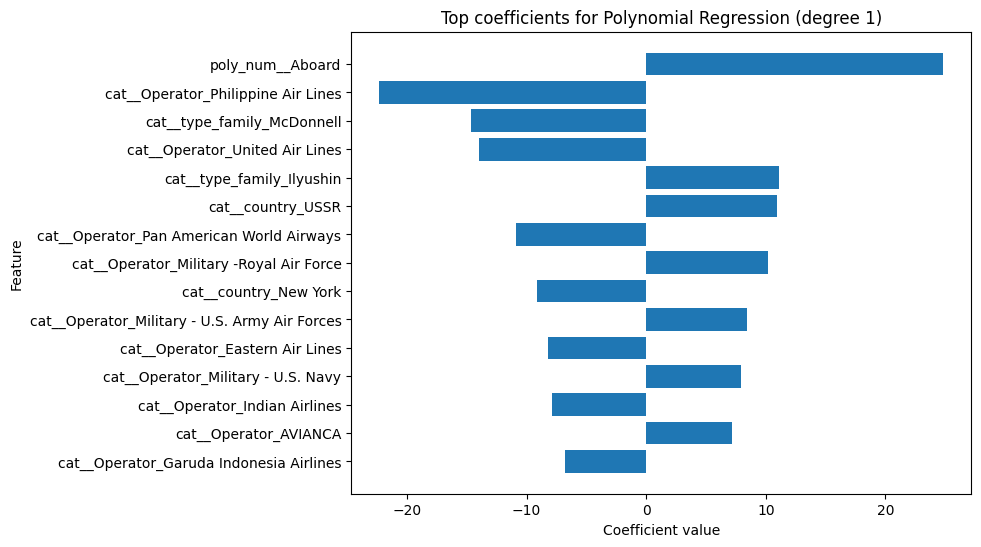

In [21]:
# Plot the largest coefficients for interpretation
if "coef_df" in globals():
    plot_df = coef_df.head(15).sort_values("abs_coefficient")

    plt.figure(figsize=(8, 6))
    plt.barh(plot_df["feature"], plot_df["coefficient"])
    plt.title(f"Top coefficients for {best_model_name}")
    plt.xlabel("Coefficient value")
    plt.ylabel("Feature")
    plt.show()

### Interpretation

The coefficient chart should be interpreted carefully:

- A **positive coefficient** suggests that, holding other processed features constant, an increase in that feature tends to increase the predicted fatalities.
- A **negative coefficient** suggests the opposite.
- Features with larger absolute coefficients have a stronger influence on the prediction **within the scaled model**.

Important caveats:
- Coefficients from scaled / encoded models are mainly useful for **relative interpretation**.
- They do **not** prove causation.
- The model is only identifying predictive patterns in the historical crash data.
- If the selected model is **Lasso Regression**, some coefficients may be exactly zero. This is expected and reflects the feature-selection effect of L1 regularisation rather than an error.

In many aviation records, `Aboard` is expected to be one of the strongest predictors because it places a practical upper bound on possible fatalities.



## 9. Train the final model on all labelled data

Once the best model has been selected, it is retrained on **all available labelled observations** before predicting the unseen dataset.

This is standard practice because:
- the model choice has already been made,
- the final pipeline can now learn from the maximum amount of labelled data,
- and the same leakage-safe preprocessing steps remain embedded inside the chosen pipeline.


In [22]:
# Refit the chosen model on the full labelled dataset
X_full = df_model[feature_cols].copy()
y_full = df_model[target_col].copy()

if best_model_name == "Simple Linear Regression":
    final_pipeline = Pipeline([
        ("preprocessor", simple_preprocessor),
        ("model", LinearRegression())
    ])

elif best_model_name == "Multiple Linear Regression":
    final_pipeline = Pipeline([
        ("preprocessor", clone(full_preprocessor)),
        ("model", LinearRegression())
    ])

elif best_model_name.startswith("Polynomial Regression"):
    final_pipeline = Pipeline([
        ("preprocessor", make_poly_preprocessor(best_degree)),
        ("model", LinearRegression())
    ])

elif best_model_name.startswith("Ridge Regression"):
    final_pipeline = Pipeline([
        ("preprocessor", clone(full_preprocessor)),
        ("model", Ridge(alpha=best_alpha))
    ])

else:
    final_pipeline = Pipeline([
        ("preprocessor", clone(full_preprocessor)),
        ("model", Lasso(alpha=best_lasso_alpha, max_iter=20000))
    ])

final_pipeline.fit(X_full, y_full)

print("Final model fitted on all labelled data using:", best_model_name)



Final model fitted on all labelled data using: Polynomial Regression (degree 1)


## 10. Predict fatalities for the unseen dataset

The unseen dataset is passed through the **same feature engineering steps** and the **same fitted preprocessing/model pipeline**.

This is important because:
- the unseen data must be transformed in exactly the same way as the training data,
- otherwise the model would be receiving different inputs at prediction time.

## Model Evaluation Strategy

Models are evaluated using a held-out test set that was not used during training.

### Metrics Used
- R² Score: measures proportion of variance explained  
- RMSE (Root Mean Squared Error): measures prediction error magnitude  

### Justification
- R² provides interpretability of model fit  
- RMSE penalises larger errors, which is important when predicting fatalities  
- Using both metrics ensures a balanced evaluation  

### Testing Approach
- Models are trained on training data only  
- Hyperparameters are selected using training data  
- Final evaluation is performed on test data to simulate real-world performance  


## Applying a real-world prediction constraint

A standard regression model can produce values that are mathematically valid but not operationally plausible. In this project, the predicted number of fatalities should never be negative and should never exceed the number of people aboard. To keep predictions realistic, the final outputs are clipped to the interval **[0, Aboard]** before they are saved. This does not change the fitted model itself; it ensures the final delivered predictions respect the domain constraint of the problem.

In [23]:
X_unseen = df_unseen_model[feature_cols].copy()

unseen_predictions = final_pipeline.predict(X_unseen)

# Post-process predictions so they obey the real-world constraint:
# predicted fatalities must be between 0 and the number of people aboard.
unseen_predictions = np.clip(unseen_predictions, 0, None)
if "Aboard" in X_unseen.columns:
    aboard_upper = X_unseen["Aboard"].fillna(np.inf).to_numpy()
    unseen_predictions = np.minimum(unseen_predictions, aboard_upper)

df_unseen_predictions = df_unseen.copy()
df_unseen_predictions["Predicted_Fatalities"] = np.round(unseen_predictions, 0).astype(int)

df_unseen_predictions.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Ground,Summary,Predicted_Fatalities
0,10/24/2004,16:30,"Martinsville, Virginia",Private - Hendrick Motorsports Inc.,NaN,"Concord, NC - Martinsville, VA",Beech 200 Super King Air,N501RH,BB-805,10.0,0.0,The plane struck a steep incline in the Bull M...,10
1,08/09/1954,00:08,"Terceira Island, Azores, Portugal",AVIANCA,NaN,"Lajes, Azores - Bermuda",Lockheed 749A-79 Constellation,HK-163,2664,30.0,0.0,Crashed into mountains after poor weather dive...,27
2,12/02/1977,NaN,"Near Al Bayda, Lebanon",Balkan Bulgarian Airlines,NaN,Jeddah - Benghazi,Tupolev TU-154B,LZ-BTN,054,165.0,0.0,After not being able to land at the scheduled ...,103
3,11/02/1988,NaN,"Near Rzeszow, Poland",LOT Polish Airlines,703,Warszawa - Rzeszow,Antonov AN-24B,SP-LTD,67302209,29.0,0.0,The plane attempted to make an emergency landi...,24
4,08/15/1957,NaN,"Copenhagen, Denmark",Aeroflot,NaN,Riga - Copenhagen,Ilyushin IL-14P,CCCP-L1874,146000607,23.0,0.0,Crashed into the harbor after hitting the chim...,23


In [24]:
# Save predictions
df_unseen_predictions.to_csv("./processed_datasets/airplanes/airplane_crashes_and_fatalities_predictions.csv", index=False)

## Conclusion, Lessons Learned, and Future Work

### Conclusion
This notebook followed a full regression workflow for predicting airplane crash fatalities: data cleaning, preprocessing, feature engineering, train/test splitting, model development, hyperparameter testing, model evaluation, model comparison, and final prediction on unseen data.

Five regression approaches were compared:
- Simple Linear Regression
- Multiple Linear Regression
- Polynomial Regression
- Ridge Regression
- Lasso Regression (included as an extracurricular extension)

The final model was selected using held-out test-set performance, with priority given to **RMSE** and then **MAE**. This makes the final choice easier to justify because the winning model is the one that produced the lowest prediction error on data not used during fitting.

### Lessons Learned
- Data leakage must be avoided by splitting data before fitting preprocessing steps  
- A simple baseline is useful because it shows whether more complex models genuinely add value  
- Polynomial features can improve flexibility, but they also increase the risk of overfitting  
- Regularisation helps control complexity when many processed features are present  
- **Ridge Regression** shrinks coefficients but keeps all predictors in the model  
- **Lasso Regression** can shrink weaker coefficients to zero, which makes it useful for feature selection as well as prediction  
- RMSE is especially important here because larger errors on severe crashes should be penalised more heavily  
- Constraining predictions to realistic values (not below 0 and not above `Aboard`) improves practical validity

### Future Work
Possible improvements include:
- using cross-validation for more robust model selection  
- testing a wider alpha grid for regularised models  
- exploring ensemble regressors such as Random Forest or Gradient Boosting  
- improving feature engineering and incorporating external aviation context where appropriate  
- examining outliers and influential cases in more depth  
- comparing whether a classification-style framing (for example high-fatality vs low-fatality crashes) adds useful decision-support value in a separate project

